# 04. The same model, fitted by NUTS

Identical generative model, identical priors, identical data to notebook
03; only the inference algorithm changes. This notebook is the
reference-posterior side of the project: NUTS with four vectorised chains
and a full diagnostic battery, the two ADVI surrogates adjudicated against
it, the warm start priced honestly and the hardware question settled. It
reads the artifacts of `scripts/fit_bsts_collapsed.py`.

In [1]:
import json
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")  # notebook JAX work is light; leave the GPU to fits

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from nemforecastdemand.config import load_config
from nemforecastdemand.evaluation.diagnostics import time_to_target_ess
from nemforecastdemand.evaluation.metrics import crps_samples
from nemforecastdemand.plotting import palette, save_figure, setup_style
from nemforecastdemand.utils import load_artifact

setup_style()
cfg = load_config()

cold, cold_meta = load_artifact(cfg.paths.artifacts / "bsts_collapsed_nuts_cold")
vi_fits = {
    kind: load_artifact(cfg.paths.artifacts / f"bsts_collapsed_vi_{kind}")
    for kind in ("meanfield", "fullrank")
}

## Why these are the only formulations on the table

The marginalised likelihood is a deliberate design choice with a
documented motivation. Written the naive way, with every half hour's
level and slope innovation as a latent draw, the same model costs two
dimensions per half hour: a year of data would mean roughly 70,000 of
them, and even an eight-week window means ~5,400. On that geometry the
toolkit collapses. Cold NUTS (four vectorised chains, 1,000 warmup plus
1,000 sampling iterations, depth-10 trees costing up to 1,023 gradient
evaluations per iteration per chain) was stopped after seventeen hours
on the RTX 4000 Ada without completing, and the full-rank guide
diverged, its dense Cholesky being underdetermined at thousands of
dimensions regardless of tuning. Those failures are findings, not
tuning accidents: trajectory-based samplers and dense covariances do
not survive thousands of correlated state dimensions.

The Kalman filter inside the likelihood removes the problem at its
source: conditional on the hyperparameters the trend is linear-Gaussian,
so the states integrate out exactly and inference works over roughly
fifty hyperparameters however long the data. The cost moves from
dimension to gradient (a sequential filter pass inside every gradient
evaluation), the full training year becomes affordable for ADVI and
NUTS alike and the states are recovered afterwards by the same filter,
which is also how every prediction in this project is Rao-Blackwellised.

## Sampler health

Everything below is the collapsed model on the full training year. Split
R-hat and bulk and tail effective sample sizes per site (vector sites
report their weakest element), divergences, energy-based fraction of
missing information (E-BFMI) and tree-depth saturation per chain. The
things to look for: R-hat at 1.00, ESS comfortably in the hundreds, zero
or near-zero divergences, E-BFMI above 0.3 and no saturated trees.

In [2]:
summary = pd.DataFrame(cold_meta["site_summary"]).set_index("site")
summary.round(4)

,size,max_rhat,min_bulk_ess,min_tail_ess
site,,,,
gamma,8,1.0044,963.8814,852.5505
beta,41,1.0035,3211.4907,2478.9724
sigma_slope,1,1.0032,2025.2865,1407.3747
gamma0,1,1.0026,1355.7426,1309.7234
phi,1,1.0011,3660.2986,2875.2702
sigma_level,1,1.0002,2994.1216,1906.7257


In [3]:
timing = cold_meta["timings_seconds"]
health = pd.DataFrame(cold_meta["chain_health"]).set_index("chain")
display_cols = pd.DataFrame(
    {
        "value": {
            "warmup (s)": timing["warmup_seconds"],
            "sampling (s)": timing["sample_seconds"],
            "min bulk ESS": cold_meta["min_bulk_ess"],
            "bulk ESS per second": cold_meta["min_bulk_ess"] / timing["sample_seconds"],
            "max R-hat": cold_meta["max_rhat"],
            "divergences": cold_meta["total_divergences"],
        }
    }
)
print(health.round(3).to_string())
display_cols.round(3)

       divergences  e_bfmi  tree_depth_saturation
chain                                            
0                0   0.960                    0.0
1                0   0.945                    0.0
2                0   0.971                    0.0
3                0   0.980                    0.0


,value
warmup (s),4.643
sampling (s),2865.886
min bulk ESS,963.881
bulk ESS per second,0.336
max R-hat,1.004
divergences,0.000


## Traces

Post-warmup traces and rank histograms for the structural hyperparameters.
Healthy chains are indistinguishable hairy caterpillars; healthy rank
histograms are flat.

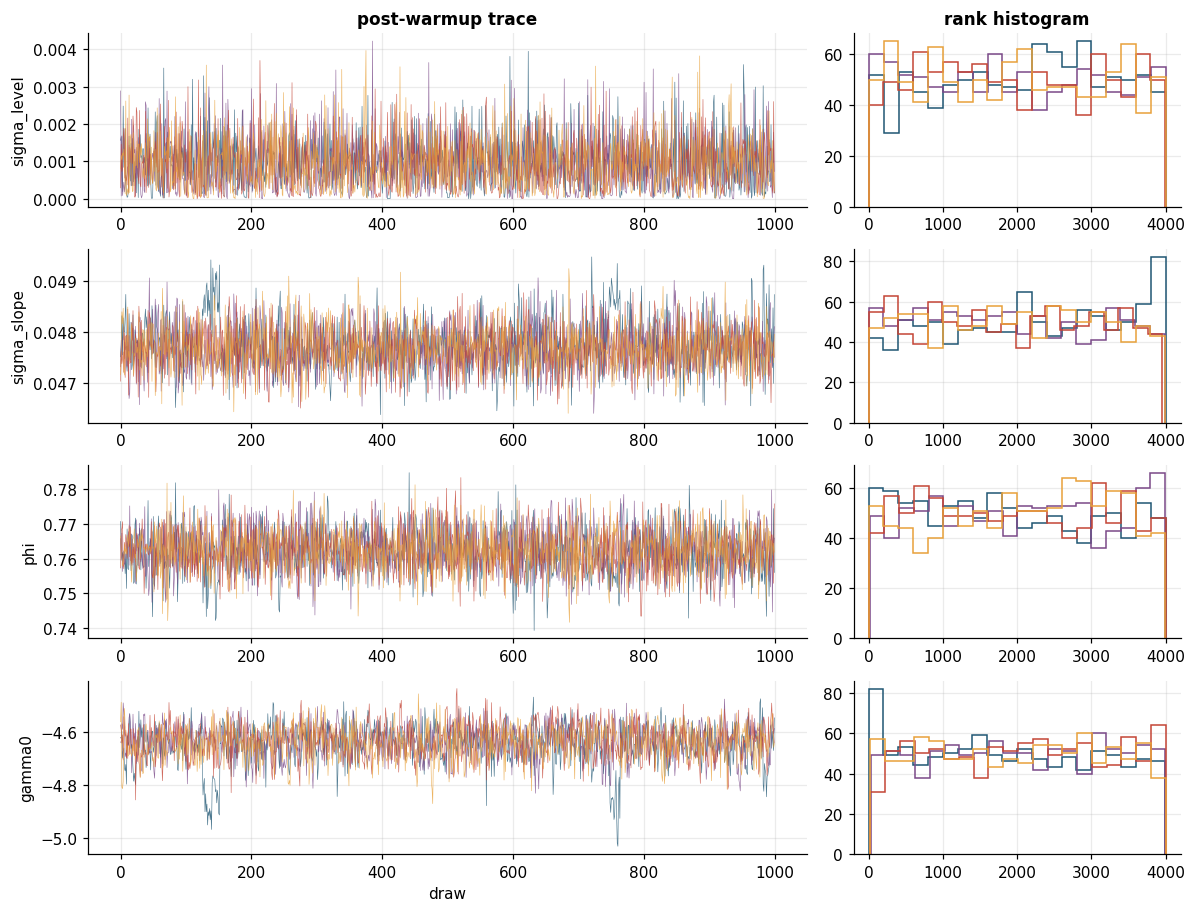

In [4]:
trace_sites = ["sigma_level", "sigma_slope", "phi", "gamma0"]
fig, axes = plt.subplots(
    len(trace_sites), 2, figsize=(11, 2.1 * len(trace_sites)), width_ratios=[2.2, 1]
)
chain_colours = ["#1f5673", "#7a4988", "#c44536", "#e8a13a"]
for row, site in enumerate(trace_sites):
    draws = cold[f"post_{site}"]
    ranks = draws.ravel().argsort().argsort().reshape(draws.shape)
    for chain in range(draws.shape[0]):
        axes[row, 0].plot(draws[chain], lw=0.4, color=chain_colours[chain], alpha=0.8)
        axes[row, 1].hist(
            ranks[chain],
            bins=20,
            histtype="step",
            color=chain_colours[chain],
            lw=1.0,
        )
    axes[row, 0].set_ylabel(site)
axes[0, 0].set_title("post-warmup trace")
axes[0, 1].set_title("rank histogram")
axes[-1, 0].set_xlabel("draw")
fig.tight_layout()
save_figure(fig, "nuts_traces", cfg.paths.figures)
plt.show()

## ADVI against the reference posterior

The question notebook 03 could not answer: which surrogate family is
closer to the truth? Here both guides fitted the collapsed model on the
same full year that NUTS certified, so the comparison is clean. Marginals
first, then the correlation structure.

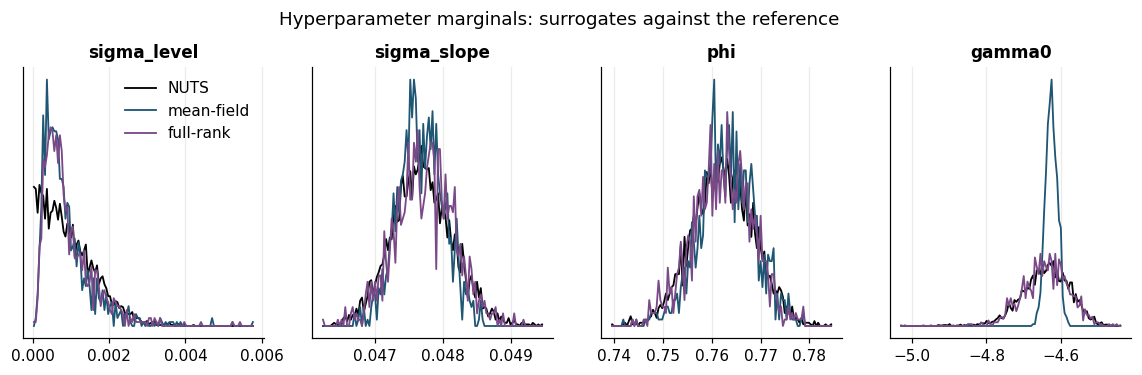

In [5]:
compare_sites = ["sigma_level", "sigma_slope", "phi", "gamma0"]
fig, axes = plt.subplots(1, len(compare_sites), figsize=(13, 3.2))
for ax, site in zip(axes, compare_sites, strict=True):
    nuts_draws = cold[f"post_{site}"].ravel()
    grid_lo = min(nuts_draws.min(), *(fit[0][f"draw_{site}"].min() for fit in vi_fits.values()))
    grid_hi = max(nuts_draws.max(), *(fit[0][f"draw_{site}"].max() for fit in vi_fits.values()))
    grid = np.linspace(grid_lo, grid_hi, 120)
    for label, draws, colour in (
        ("NUTS", nuts_draws, "black"),
        ("mean-field", vi_fits["meanfield"][0][f"draw_{site}"], palette("demand")),
        ("full-rank", vi_fits["fullrank"][0][f"draw_{site}"], palette("accent")),
    ):
        density = np.histogram(draws, bins=grid, density=True)[0]
        centres = (grid[:-1] + grid[1:]) / 2
        ax.plot(centres, density, label=label, color=colour, lw=1.2)
    ax.set_title(site)
    ax.set_yticks([])
axes[0].legend()
fig.suptitle("Hyperparameter marginals: surrogates against the reference", y=1.04)
save_figure(fig, "advi_vs_nuts_marginals", cfg.paths.figures)
plt.show()

In [6]:
rows = {}
for site in compare_sites:
    nuts_sd = cold[f"post_{site}"].ravel().std()
    rows[site] = {
        "sd NUTS": nuts_sd,
        "sd MF / NUTS": vi_fits["meanfield"][0][f"draw_{site}"].std() / nuts_sd,
        "sd FR / NUTS": vi_fits["fullrank"][0][f"draw_{site}"].std() / nuts_sd,
    }
pd.DataFrame(rows).T.round(3)

,sd NUTS,sd MF / NUTS,sd FR / NUTS
sigma_level,0.001,0.959,0.931
sigma_slope,0.000,0.727,0.952
phi,0.006,0.901,0.969
gamma0,0.066,0.236,0.912


Pairwise correlations among hyperparameters: NUTS defines the target,
full-rank can chase it and mean-field is structurally zero.

In [7]:
pair_sites = ["sigma_level", "sigma_slope", "phi", "gamma0"]


def pair_correlations(draw_map: dict[str, np.ndarray]) -> pd.Series:
    out = {}
    for i, a in enumerate(pair_sites):
        for b in pair_sites[i + 1 :]:
            out[f"{a} ~ {b}"] = np.corrcoef(draw_map[a].ravel(), draw_map[b].ravel())[0, 1]
    return pd.Series(out)


pd.DataFrame(
    {
        "NUTS": pair_correlations({s: cold[f"post_{s}"] for s in pair_sites}),
        "full-rank ADVI": pair_correlations(
            {s: vi_fits["fullrank"][0][f"draw_{s}"] for s in pair_sites}
        ),
        "mean-field ADVI": pair_correlations(
            {s: vi_fits["meanfield"][0][f"draw_{s}"] for s in pair_sites}
        ),
    }
).round(3)

,NUTS,full-rank ADVI,mean-field ADVI
sigma_level ~ sigma_slope,-0.026,-0.047,0.081
sigma_level ~ phi,-0.017,-0.006,0.001
sigma_level ~ gamma0,-0.021,-0.005,0.031
sigma_slope ~ phi,-0.362,-0.309,-0.048
sigma_slope ~ gamma0,-0.393,-0.346,-0.038
phi ~ gamma0,0.233,0.228,0.090


## Predictive accuracy, NUTS against ADVI

Same Rao-Blackwellised prediction pipeline, same test origins, archived
forecast weather. The full cross-model table lives in notebook 05; this
is the inference-to-inference comparison at a fixed model.

In [8]:
y_test = cold["y_test"]
crps_rows = {}
for label, paths in (
    ("collapsed NUTS", cold["forecast_paths"]),
    ("collapsed ADVI mean-field", vi_fits["meanfield"][0]["forecast_paths"]),
    ("collapsed ADVI full-rank", vi_fits["fullrank"][0]["forecast_paths"]),
):
    crps_rows[label] = np.mean(
        [crps_samples(y_test[i], paths[:, i, :]).mean() for i in range(y_test.shape[0])]
    )
pd.Series(crps_rows, name="test CRPS (MW)").to_frame().round(1)

,test CRPS (MW)
collapsed NUTS,497.6
collapsed ADVI mean-field,498.6
collapsed ADVI full-rank,496.8


## Aleatoric against epistemic uncertainty

Conditional on a hyperparameter draw the model is linear-Gaussian, so
the predictive variance splits exactly into four sources: **parameter**
(posterior spread of per-draw predictive means) and **state** (precision
of the level and slope estimate at the origin) are epistemic, while
**process** (future trend innovations) and **observation** (the
heteroskedastic noise floor) are aleatoric. With NUTS as the reference,
the epistemic share doubles as an inference diagnostic: a surrogate that
under-states posterior spread reports too little epistemic uncertainty,
and that bias survives into any downstream decision that hinges on
whether more data would help.

/home/s95717/miniforge3/envs/nem-demand-forecast/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


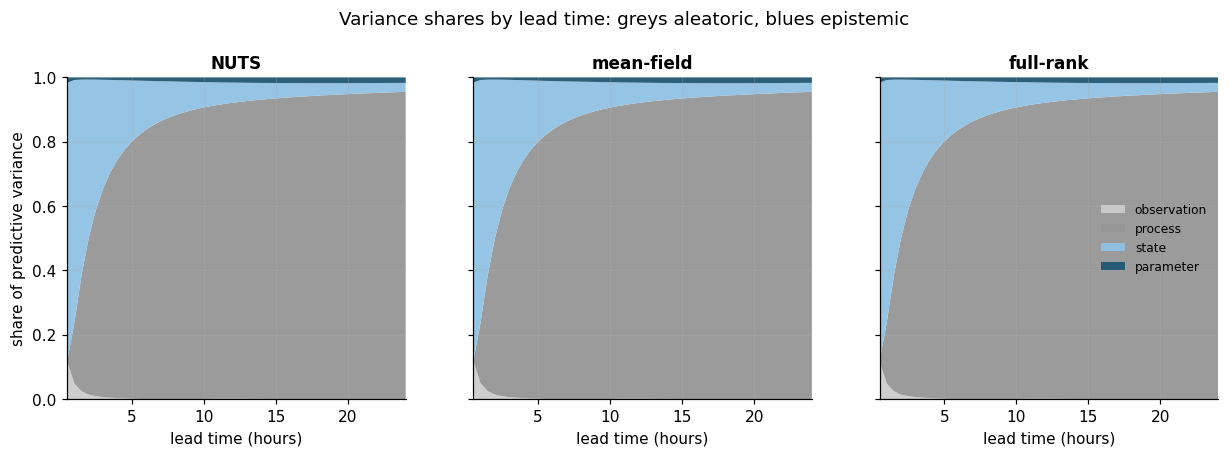

In [9]:
from nemforecastdemand.data.loaders import load_splits
from nemforecastdemand.models import bsts
from nemforecastdemand.models.predict import variance_decomposition
from nemforecastdemand.splits import rolling_origins

splits = load_splits(cfg.paths.processed)
panel = pd.concat([splits["train"], splits["validation"], splits["test"]])
max_lag = max(cfg.features.demand_lags)
fit_index = panel.index[panel.index < splits["test"].index[0]][max_lag:]
inputs = bsts.prepare_inputs(panel, cfg, fit_index)
test_origins = rolling_origins(splits["test"].index, panel.index, cfg.origins, cfg.horizon, max_lag)

sites = tuple(s for s in bsts.HYPER_SITES if s not in ("level_init", "slope_init"))


def with_marginalised_inits(draws: dict) -> dict:
    zeros = np.zeros(draws["sigma_level"].shape[0], dtype=np.float32)
    return {**draws, "level_init": zeros, "slope_init": zeros}


nuts_flat = {
    name: cold[f"post_{name}"].reshape(-1, *cold[f"post_{name}"].shape[2:]) for name in sites
}
keep = max(nuts_flat["sigma_level"].shape[0] // 1000, 1)
draw_sets = {
    "NUTS": with_marginalised_inits({name: value[::keep] for name, value in nuts_flat.items()}),
    "mean-field": with_marginalised_inits(
        {name: vi_fits["meanfield"][0][f"draw_{name}"] for name in sites}
    ),
    "full-rank": with_marginalised_inits(
        {name: vi_fits["fullrank"][0][f"draw_{name}"] for name in sites}
    ),
}
decomp = {
    label: variance_decomposition(draws, inputs, panel, cfg, test_origins)
    for label, draws in draw_sets.items()
}

component_order = ["observation", "process", "state", "parameter"]
component_colours = {
    "observation": "#cccccc",
    "process": "#969696",
    "state": "#8fc1e3",
    "parameter": "#1f5673",
}
hours = (np.arange(cfg.horizon) + 1) / 2
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8), sharey=True)
for ax, (label, parts) in zip(axes, decomp.items(), strict=True):
    total = sum(parts.values())
    shares = np.stack([(parts[name] / total).mean(axis=0) for name in component_order])
    ax.stackplot(
        hours,
        shares,
        labels=component_order,
        colors=[component_colours[n] for n in component_order],
        alpha=0.95,
    )
    ax.set_title(label)
    ax.set_xlabel("lead time (hours)")
    ax.set_ylim(0, 1)
    ax.set_xlim(hours[0], hours[-1])
axes[0].set_ylabel("share of predictive variance")
axes[2].legend(loc="center right", fontsize=8)
fig.suptitle("Variance shares by lead time: greys aleatoric, blues epistemic", y=1.04)
save_figure(fig, "collapsed_variance_decomposition", cfg.paths.figures)
plt.show()

In [10]:
rows = {}
for label, parts in decomp.items():
    total = sum(parts.values())
    rows[label] = {f"{name} share": float((parts[name] / total).mean()) for name in component_order}
    rows[label]["epistemic share"] = rows[label]["state share"] + rows[label]["parameter share"]
    rows[label]["mean predictive sd (MW)"] = float(np.sqrt(total.mean()))
pd.DataFrame(rows).T.round(3)

,observation share,process share,state share,parameter share,epistemic share,mean predictive sd (MW)
NUTS,0.005,0.839,0.141,0.015,0.156,1488.038
mean-field,0.005,0.839,0.141,0.015,0.156,1490.692
full-rank,0.005,0.839,0.141,0.015,0.156,1487.797


## Pricing the ADVI warm start

The warm runs seed every chain from the fitted surrogate and freeze the
inverse mass matrix to the surrogate covariance (diagonal from
mean-field, dense from full-rank), keeping only step-size adaptation. The
accounting is strict:

- **cold total** = full warmup + sampling, everything adapted from scratch;
- **warm total** = ADVI fit + reduced warmup + sampling.

Comparison happens at matched quality: wall-clock to a target bulk ESS of
400 with R-hat under 1.01 and no divergences. A shorter warmup that mixes
worse is not faster, it is unfinished.

In [11]:
target = cfg.warm_start.target_bulk_ess
runs = {"cold": cold_meta}
for kind in ("meanfield", "fullrank"):
    for reduced in cfg.warm_start.reduced_warmup:
        stem = f"bsts_collapsed_nuts_warm_{kind}_w{reduced}"
        runs[f"warm {kind} w={reduced}"] = load_artifact(cfg.paths.artifacts / stem)[1]

rows = {}
for name, meta in runs.items():
    run_timing = meta["timings_seconds"]
    advi_seconds = meta.get("advi_seconds", 0.0)
    to_target = time_to_target_ess(
        run_timing["warmup_seconds"], run_timing["sample_seconds"], meta["min_bulk_ess"], target
    )
    quality_ok = meta["max_rhat"] < cfg.warm_start.rhat_threshold and meta["total_divergences"] == 0
    rows[name] = {
        "ADVI (s)": advi_seconds,
        "warmup (s)": run_timing["warmup_seconds"],
        "sampling (s)": run_timing["sample_seconds"],
        "min bulk ESS": meta["min_bulk_ess"],
        "max R-hat": meta["max_rhat"],
        "divergences": meta["total_divergences"],
        f"total to ESS {target:.0f} (s)": advi_seconds + to_target,
        "quality met": quality_ok,
    }
warm_table = pd.DataFrame(rows).T
warm_table.round(3)

,ADVI (s),warmup (s),sampling (s),min bulk ESS,max R-hat,divergences,total to ESS 400 (s),quality met
cold,0.0,4.643493,2865.885889,963.881417,1.004399,0,1193.954061,True
warm meanfield w=100,698.870147,5.791758,50.961719,349.558632,1.013305,0,762.977409,False
warm meanfield w=300,698.870147,3.89065,151.506278,448.557573,1.01039,0,837.86611,False
warm fullrank w=100,550.057762,4.539176,28.602008,1982.576824,1.005849,0,560.367611,True
warm fullrank w=300,550.057762,4.25656,83.91703,1453.02508,1.00439,0,577.415652,True


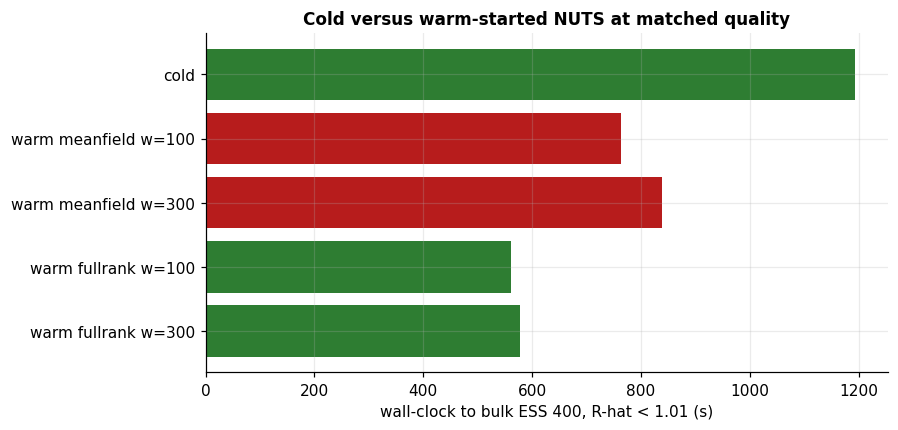

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
column = f"total to ESS {target:.0f} (s)"
bars = warm_table[column].astype(float)
colours_bar = ["#2e7d32" if ok else "#b71c1c" for ok in warm_table["quality met"]]
ax.barh(bars.index[::-1], bars[::-1], color=colours_bar[::-1])
ax.set_xlabel(f"wall-clock to bulk ESS {target:.0f}, R-hat < {cfg.warm_start.rhat_threshold} (s)")
ax.set_title("Cold versus warm-started NUTS at matched quality")
save_figure(fig, "warm_start_accounting", cfg.paths.figures)
plt.show()

Reading the table honestly: the warm starts must amortise the ADVI fit
they depend on, so they only win when the reduced warmup plus sampling
saves more than the surrogate cost, and only count at all when quality
holds (green bars). Any red bar is a warm start that bought speed with
broken mixing or divergences, the failure mode flagged in the brief: a
surrogate that under-estimates variance hands the sampler a mis-scaled
mass matrix. At fifty dimensions the surrogate covariance is cheap to
estimate well, which is exactly the regime where the warm start should
shine; notebook 05 carries the timing column into the final comparison.

## GPU against CPU

The entire collapsed suite was refitted on 32 CPU cores with the same
code, the same settings and the same explicit timing barriers, so every
row is a like-for-like wall-clock comparison. ADVI rows report the fit;
NUTS rows report warmup plus sampling.

In [13]:
def wall_seconds(meta: dict) -> float:
    t = meta["timings_seconds"]
    if "fit_seconds" in t:
        return t["fit_seconds"]
    return t["warmup_seconds"] + t["sample_seconds"]


stems = {
    "ADVI mean-field": "bsts_collapsed_vi_meanfield",
    "ADVI full-rank": "bsts_collapsed_vi_fullrank",
    "NUTS cold": "bsts_collapsed_nuts_cold",
}
for kind in ("meanfield", "fullrank"):
    for reduced in cfg.warm_start.reduced_warmup:
        stems[f"NUTS warm {kind} w={reduced}"] = f"bsts_collapsed_nuts_warm_{kind}_w{reduced}"

bench_rows = {}
for label, stem in stems.items():
    gpu_meta = json.loads((cfg.paths.artifacts / f"{stem}.json").read_text())
    cpu_meta = json.loads((cfg.paths.artifacts / f"{stem}.cpu.json").read_text())
    gpu_s, cpu_s = wall_seconds(gpu_meta), wall_seconds(cpu_meta)
    bench_rows[label] = {"GPU (s)": gpu_s, "CPU (s)": cpu_s, "speed-up": cpu_s / gpu_s}
pd.DataFrame(bench_rows).T.round(2)

,GPU (s),CPU (s),speed-up
ADVI mean-field,3351.86,690.03,0.21
ADVI full-rank,3358.00,521.51,0.16
NUTS cold,2870.53,2172.03,0.76
NUTS warm meanfield w=100,56.75,283.36,4.99
NUTS warm meanfield w=300,155.40,317.02,2.04
NUTS warm fullrank w=100,33.14,177.16,5.35
NUTS warm fullrank w=300,88.17,218.56,2.48


## Summary

- Written with explicit states the model defeats NUTS (seventeen hours,
  incomplete, stopped) and the full-rank guide alike; the marginalised
  likelihood is what makes the rest of this notebook possible.
- On the collapsed model NUTS passes its full diagnostic battery on a
  full year of data and stands as the reference posterior.
- The surrogate adjudication, the warm-start accounting at matched
  quality and the hardware verdict are in the tables above; their
  narratives are written against the executed numbers.